# PADL coursework

In [39]:
import sklearn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gensim

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, accuracy_score
from scipy.stats import mode

from gensim.models import Word2Vec

## Q1

### A

1.0


/Users/elijah/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.307e-02, tolerance: 2.312e-02
  model = cd_fast.enet_coordinate_descent(
/Users/elijah/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.228e-01, tolerance: 2.312e-02
  model = cd_fast.enet_coordinate_descent(
/Users/elijah/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing reg

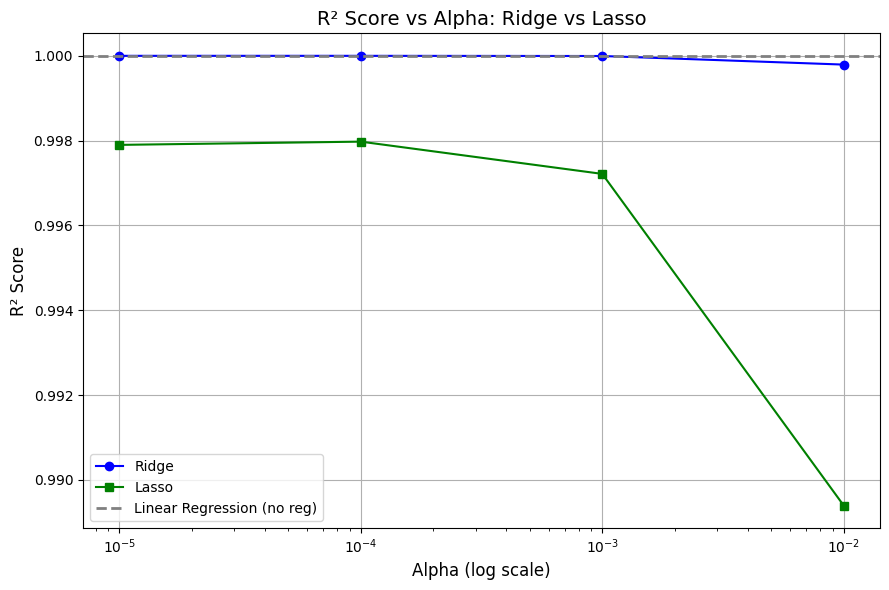

In [ ]:
# Get data from PADL-Q11-train.csv
data = np.loadtxt('datasets/PADL-Q11-train.csv', delimiter=',', skiprows=1)

# Split data into X and y 
X = data[:, :-1]
y = data[:, -1]

# Split the available data into training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardise X values
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Apply PCA
pca = PCA(n_components=0.99) 
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)

# Create polynomial features
poly = PolynomialFeatures(degree=2)  # Try higher degrees like 2 or 3
X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)

alphas = [0.01, 0.001, 0.0001, 0.00001]
lasso_r2_scores = []
ridge_r2_scores = []

# Loop through potential alpha values for both lasso and ridge regression
for a in alphas:
    # Lasso
    model = Lasso(alpha=a)
    model.fit(X_train_poly, y_train)
    y_pred = model.predict(X_val_poly)
    r2 = r2_score(y_val, y_pred)
    lasso_r2_scores.append(r2)

    # Ridge
    model = Ridge(alpha=a)
    model.fit(X_train_poly, y_train)
    y_pred = model.predict(X_val_poly)
    r2 = r2_score(y_val, y_pred)
    ridge_r2_scores.append(r2)
    

# Also plot linear regression model, no alphas needed
model = LinearRegression()
model.fit(X_train_poly, y_train)
y_pred = model.predict(X_val_poly)
lin_r2 = r2_score(y_val, y_pred)
print(lin_r2)


# Plot data using log values for alphas
plt.figure(figsize=(9, 6))
plt.plot(alphas, ridge_r2_scores, marker='o', color='blue', label='Ridge', linestyle='-', markersize=6)
plt.plot(alphas, lasso_r2_scores, marker='s', color='green', label='Lasso', linestyle='-', markersize=6)
plt.axhline(lin_r2, color='gray', linestyle='--', label='Linear Regression (no reg)', linewidth=2)

plt.xscale('log')
plt.xlabel('Alpha (log scale)', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('R² Score vs Alpha: Ridge vs Lasso', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



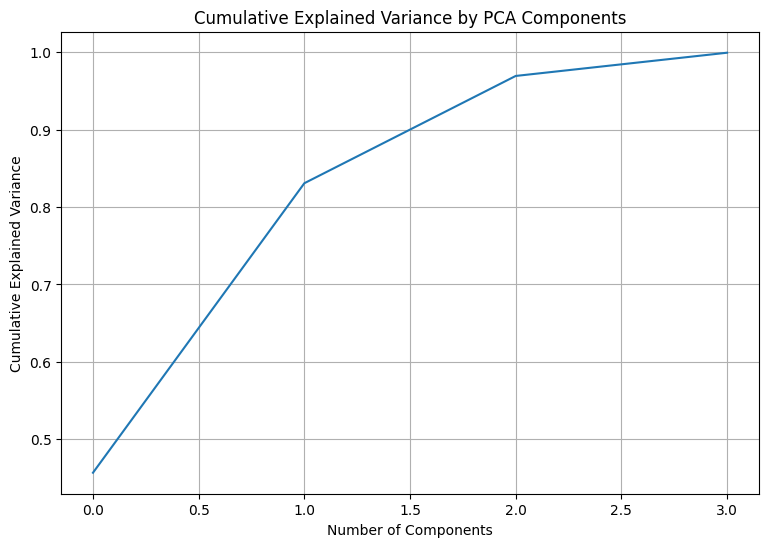

In [27]:
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(9, 6))
plt.plot(cumulative_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid(True)
plt.show()

### B

In [6]:
data = np.loadtxt('datasets/PADL-Q12-train.csv', delimiter=',', skiprows=1)

### C

In [19]:
data = np.loadtxt('datasets/PADL-Q13-train.csv', delimiter=',', skiprows=1)

## Q2

### A

/Users/elijah/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/elijah/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/elijah/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


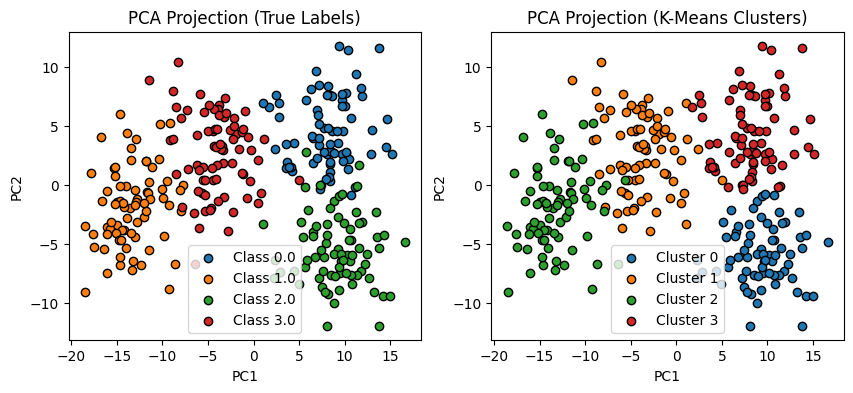

In [14]:
# Load data from PADL-Q2.csv
data = np.loadtxt('datasets/PADL-Q2.csv', delimiter=',', skiprows=1)

# Extract into features and labels
X = data[:, :-1]
Y = data[:, -1]

# Might need standardising or normalisation

# Define number of clusters
num_clusters = len(np.unique(Y))

# K-means on original data
kmeans = KMeans(n_clusters=num_clusters)
Y_kmeans = kmeans.fit_predict(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create figure
plt.figure(figsize=(10,4))

# Plot PCA with true labels
plt.subplot(1, 2, 1)
for label in np.unique(Y):
    plt.scatter(X_pca[Y == label, 0], X_pca[Y == label, 1], label=f"Class {label}", edgecolor="k")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (True Labels)")
plt.legend()

# Plot PCA projection with K-Means Clusters
plt.subplot(1, 2, 2)
for cluster in range(num_clusters):
    plt.scatter(X_pca[Y_kmeans == cluster, 0], X_pca[Y_kmeans == cluster, 1], label=f"Cluster {cluster}", edgecolor="k")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (K-Means Clusters)")
plt.legend()

### B

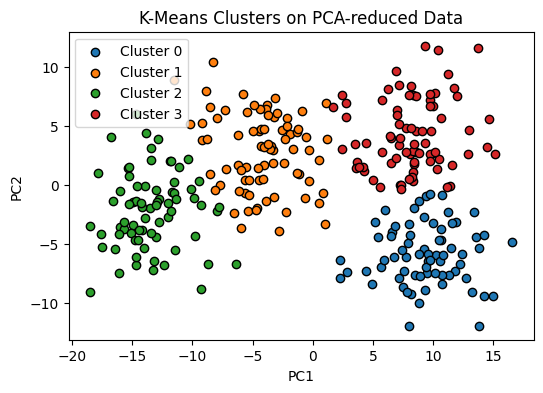

In [15]:
# Apply K-means to PCA data
kmeans_pca = KMeans(n_clusters=num_clusters)
Y_kmeans_pca = kmeans_pca.fit_predict(X_pca)

# Plot predictions from kmeans after PCA
plt.figure(figsize=(6, 4))

for cluster in range(num_clusters):
    plt.scatter(X_pca[Y_kmeans_pca == cluster, 0], X_pca[Y_kmeans_pca == cluster, 1], label=f"Cluster {cluster}", edgecolor="k")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters on PCA-reduced Data")
plt.legend()
plt.show()

### C

## Q3

### A

In [ ]:
# Load data from PADL-Q3.txt
data = np.loadtxt('datasets/PADL-Q3.txt', delimiter=' ')


### B

## Q4

### A

In [19]:
data = np.genfromtxt('datasets/body_measurements.csv', delimiter=',', skip_header=1, filling_values=np.nan)

### B

## Q5

### A

### B

## Q6

### A

### B

### C